<a href="https://colab.research.google.com/github/jacy-sys/Titanic-dataset.ipynb/blob/main/Titanic_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [109]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [110]:
!ls "/content/drive/MyDrive/Titanic dataset"

Titanic-Dataset.csv


In [111]:
import pandas as pd

titanic = pd.read_csv("/content/drive/MyDrive/Titanic dataset/Titanic-Dataset.csv")
print("titanic dataset shape:",titanic.shape)


titanic dataset shape: (891, 12)


In [112]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [113]:
titanic.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [114]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [115]:
titanic.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [116]:
titanic.median(numeric_only=True)


,0
PassengerId,446.0000
Survived,0.0000
Pclass,3.0000
Age,28.0000
SibSp,0.0000
Parch,0.0000
Fare,14.4542


In [117]:
titanic["Age"].median()

28.0

In [118]:
titanic["Age"] = titanic["Age"].fillna('median')

In [119]:
titanic['Embarked'] =titanic['Embarked'].fillna('mode')

In [120]:
titanic.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [121]:
titanic.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [122]:
titanic.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [123]:
titanic.duplicated().sum()

np.int64(0)

In [124]:
import pandas as pd

# Select only numeric columns
numeric_cols = titanic.select_dtypes(include=['number'])

# Create an empty dictionary to store outlier counts
outlier_counts = {}

# Loop through each numeric column
for column in numeric_cols.columns:

    Q1 = numeric_cols[column].quantile(0.25)
    Q3 = numeric_cols[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = numeric_cols[(numeric_cols[column] < lower_bound) |
                            (numeric_cols[column] > upper_bound)]

    outlier_counts[column] = len(outliers)

# Display outlier count per column
print(outlier_counts)


{'PassengerId': 0, 'Survived': 0, 'Pclass': 0, 'SibSp': 46, 'Parch': 213, 'Fare': 116}


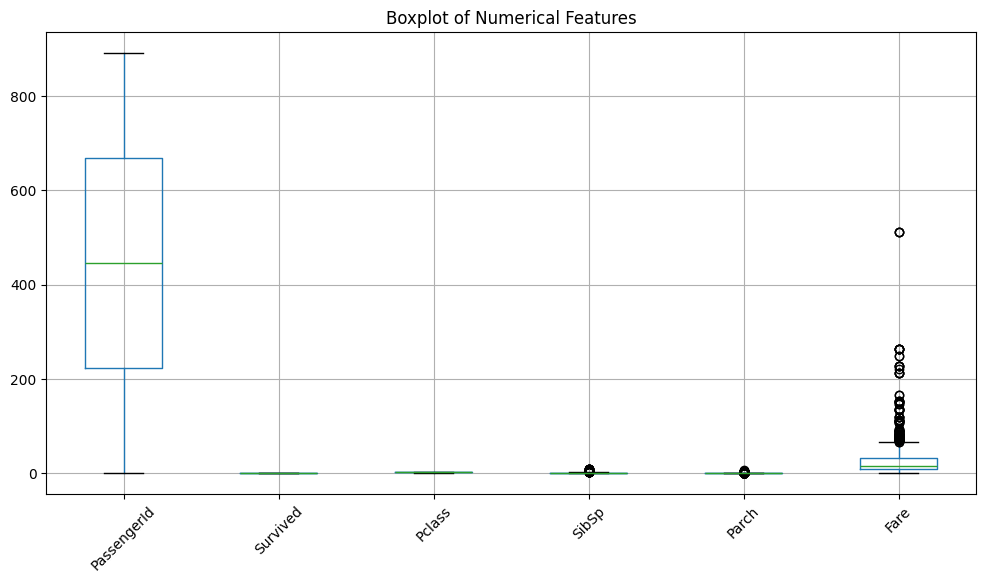

In [125]:
import matplotlib.pyplot as plt

# Select only numeric columns
numeric_cols = titanic.select_dtypes(include=['number'])

# Create boxplot
plt.figure(figsize=(12,6))
numeric_cols.boxplot()
plt.xticks(rotation=45)
plt.title("Boxplot of Numerical Features")
plt.show()

In [126]:
# Select numeric columns
numeric_cols = titanic.select_dtypes(include=['number'])

# Create a copy of dataset
titanic_clean = titanic.copy()

for column in numeric_cols.columns:

    Q1 = titanic_clean[column].quantile(0.25)
    Q3 = titanic_clean[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    titanic_clean = titanic_clean[
        (titanic_clean[column] >= lower_bound) &
        (titanic_clean[column] <= upper_bound)
    ]

print("Original shape:", titanic.shape)
print("New shape after removing outliers:", titanic_clean.shape)


Original shape: (891, 12)
New shape after removing outliers: (591, 12)


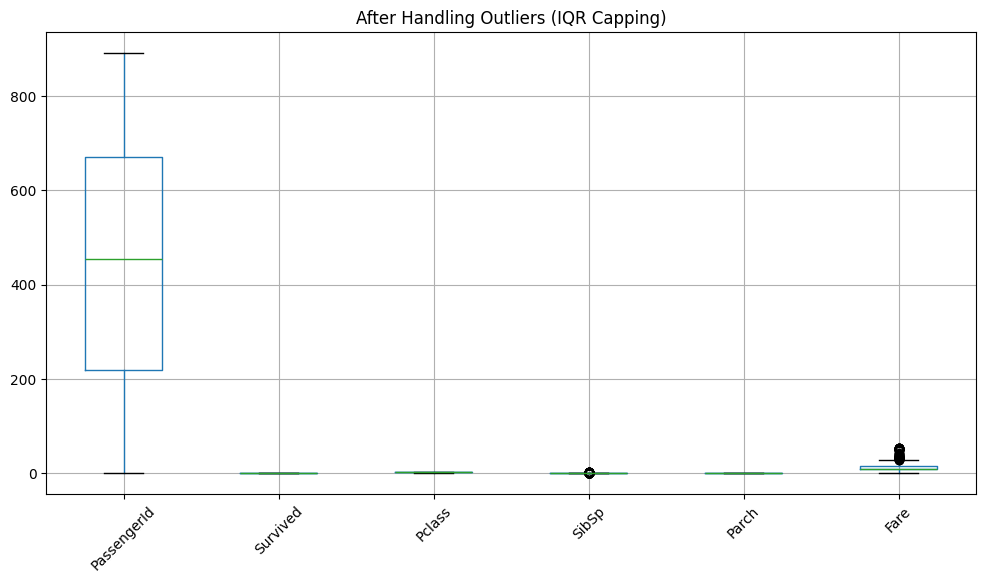

In [127]:
plt.figure(figsize=(12,6))
titanic_clean.select_dtypes(include=['number']).boxplot()
plt.xticks(rotation=45)
plt.title("After Handling Outliers (IQR Capping)")
plt.show()


In [128]:
import pandas as pd

print(type(titanic_clean))

<class 'pandas.core.frame.DataFrame'>


In [129]:
titanic_clean.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,median,0,0,330877,8.4583,NaN,Q


In [133]:
# Define age group function
def age_group(age):
    if age <= 12:
        return 'Children'
    elif age <= 19:
        return 'Teens'
    elif age <= 100:
        return 'Adults'
    else:
        return 'Seniors'

# Apply function
titanic_clean['AgeGroup'] = titanic_clean['Age'].apply(age_group)

# Preview result
print(titanic_clean[['Age','AgeGroup']].head())

    Age AgeGroup
0  22.0   Adults
2  26.0   Adults
3  35.0   Adults
4  35.0   Adults
5  28.0   Adults


In [135]:
titanic_clean['AgeGroup'].head(10)

,AgeGroup
0,Adults
2,Adults
3,Adults
4,Adults
5,Adults
6,Adults
9,Teens
11,Adults
12,Adults
14,Teens


In [ ]:
import matplotlib.pyplot as plt

# Ensure 'Age' column is numeric by replacing 'median' string with the float 28.0
titanic_clean['Age'] = titanic_clean['Age'].replace('median', 28.0).astype(float)

# Histogram for Age
plt.figure()
plt.hist(titanic_clean['Age'], bins=30)
plt.title('Histogram of Age (Before Scaling)')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()


# Histogram for Fare
plt.figure()
plt.hist(titanic_clean['Fare'], bins=30)
plt.title('Histogram of Fare (Before Scaling)')
plt.xlabel('Fare')
plt.ylabel('Frequency')
plt.show()

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Select columns - Correct column names
cols = ['Age', 'Fare']

# Replace 'median' string in 'Age' column with the numeric median value (28.0)
# and convert to numeric type, as MinMaxScaler expects numerical data.
titanic_clean['Age'] = titanic_clean['Age'].replace('median', 28.0).astype(float)

# Initialize scaler
scaler = MinMaxScaler()

# Apply normalization
titanic_clean[cols] = scaler.fit_transform(titanic_clean[cols])

# Preview result
print(titanic_clean[cols].head())

In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Apply standardization to Age and Fare
titanic_clean[['Age', 'Fare']] = scaler.fit_transform(titanic_clean[['Age', 'Fare']])

# Preview results
print(titanic_clean[['Age', 'Fare']].head())

In [ ]:
print("Means:")
print(titanic_clean[['Age', 'Fare']].mean())

print("\nStandard Deviations:")
print(titanic_clean[['Age', 'Fare']].std())

In [ ]:
import matplotlib.pyplot as plt

# Histogram for Normalized Age
plt.figure()
plt.hist(titanic_clean['Age'], bins=30)
plt.title('Histogram of Age (After Normalization)')
plt.xlabel('Normalized Age')
plt.ylabel('Frequency')
plt.show()


# Histogram for Normalized Fare
plt.figure()
plt.hist(titanic_clean['Fare'], bins=30)
plt.title('Histogram of Fare (After Normalization)')
plt.xlabel('Normalized Fare')
plt.ylabel('Frequency')
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histogram for Age after standardization
plt.figure(figsize=(8, 5))
sns.histplot(titanic_clean['Age'], bins=30, kde=True)
plt.title('Histogram of Age (After Standardization)')
plt.xlabel('Age (Standardized)')
plt.ylabel('Frequency')
plt.show()

# Histogram for Fare after standardization
plt.figure(figsize=(8, 5))
sns.histplot(titanic_clean['Fare'], bins=30, kde=True)
plt.title('Histogram of Fare (After Standardization)')
plt.xlabel('Fare (Standardized)')
plt.ylabel('Frequency')
plt.show()

In [ ]:
# Convert to lowercase (just in case)
titanic_clean['Sex'] = titanic_clean['Sex'].str.lower()

# Apply label encoding
titanic_clean['Sex'] = titanic_clean['Sex'].map({
    'male': 0,
    'female': 1
})

# Preview result
print(titanic_clean[['Sex']].head())

In [ ]:
# Perform one-hot encoding
titanic_clean = pd.get_dummies(titanic_clean, columns=['Embarked'], drop_first=True)

# Preview results
print(titanic_clean.head())

In [ ]:
titanic_clean.head(10
                   )

In [ ]:
# Convert boolean columns to integers
bool_cols = titanic_clean.select_dtypes(include='bool').columns

titanic_clean[bool_cols] = titanic_clean[bool_cols].astype(int)

# Check result
print(titanic_clean.head())

In [ ]:
titanic_clean.head(10)


In [ ]:
#checking the shape of the dataset after one hot encoding
titanic_clean.shape

In [ ]:
# Create FamilySize feature
titanic_clean['FamilySize'] = titanic_clean['SibSp'] + titanic_clean['Parch'] + 1

# Preview result
print(titanic_clean[['SibSp','Parch','FamilySize']].head())

In [ ]:
# Define age group function
def age_group(age):
    if age <= 12:
        return 'Children'
    elif age <= 19:
        return 'Teens'
    elif age <= 59:
        return 'Adults'
    else:
        return 'Seniors'

# Apply function
titanic_clean['AgeGroup'] = titanic_clean['Age'].apply(age_group)

# Preview result
print(titanic_clean[['Age','AgeGroup']].head())

In [ ]:
# Extract title from Name column
titanic_clean['Title'] = titanic_clean['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

# Preview result
print(titanic_clean[['Name','Title']].head())

# Task
Fix the `TypeError` in the 'Age' column by replacing the string 'median' with the numeric median value of 28.0, then re-apply the `age_group` function to create the 'AgeGroup' feature. Finally, display the head of the 'Age' and 'AgeGroup' columns to verify the changes.

## Fix Age column type

### Subtask:
Convert the 'Age' column to a numeric type (float), replacing the string 'median' with the actual median age (28.0) found earlier in the notebook. This will allow numerical comparisons in the `age_group` function.


**Reasoning**:
The previous attempt to apply the `age_group` function failed because the 'Age' column contained string values ('median'). This step will explicitly convert the 'Age' column to a numeric type, replacing the string 'median' with the actual median value of 28.0. This ensures that the `age_group` function can perform numerical comparisons correctly.



/tmp/ipython-input-1792955550.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  titanic_clean['Age'] = titanic_clean['Age'].replace('median', 28.0).astype(float)


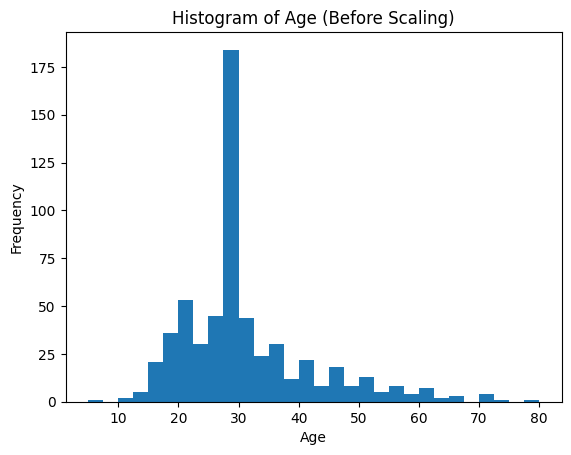

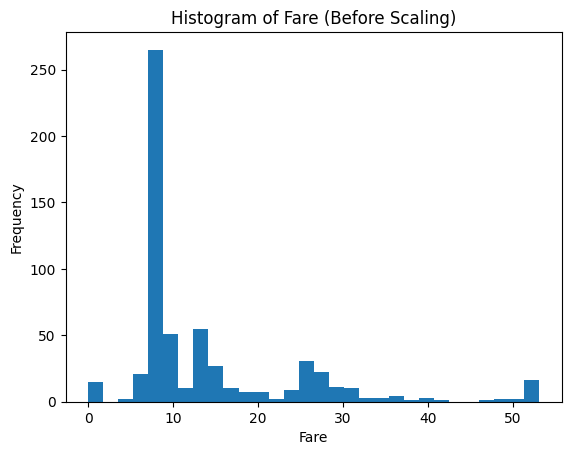

In [131]:
import matplotlib.pyplot as plt

# Ensure 'Age' column is numeric by replacing 'median' string with the float 28.0
titanic_clean['Age'] = titanic_clean['Age'].replace('median', 28.0).astype(float)

# Histogram for Age
plt.figure()
plt.hist(titanic_clean['Age'], bins=30)
plt.title('Histogram of Age (Before Scaling)')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()


# Histogram for Fare
plt.figure()
plt.hist(titanic_clean['Fare'], bins=30)
plt.title('Histogram of Fare (Before Scaling)')
plt.xlabel('Fare')
plt.ylabel('Frequency')
plt.show()